In [52]:
# MARKETING CAMPAIGN ........
# STEP:1
import pandas as pd
file_path = "/content/marketing_data.csv"
df = pd.read_csv(file_path)
df.head()


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,"$84,835.00",0,0,6/16/14,0,189,...,6,1,0,0,0,0,0,1,0,SP
1,1,1961,Graduation,Single,"$57,091.00",0,0,6/15/14,0,464,...,7,5,0,0,0,0,1,1,0,CA
2,10476,1958,Graduation,Married,"$67,267.00",0,1,5/13/14,0,134,...,5,2,0,0,0,0,0,0,0,US
3,1386,1967,Graduation,Together,"$32,474.00",1,1,5/11/14,0,10,...,2,7,0,0,0,0,0,0,0,AUS
4,5371,1989,Graduation,Single,"$21,474.00",1,0,4/8/14,0,6,...,2,7,1,0,0,0,0,1,0,SP


In [ ]:
#Examine data types
df.dtypes

,0
ID,int64
Year_Birth,int64
Education,object
Marital_Status,object
Income,object
Kidhome,int64
Teenhome,int64
Dt_Customer,object
Recency,int64
MntWines,int64


In [ ]:
# checking format and sample value, dt_customer is not in date format
df['Dt_Customer'].head()

,Dt_Customer
0,6/16/14
1,6/15/14
2,5/13/14
3,5/11/14
4,4/8/14


In [ ]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], errors='coerce')
df['Dt_Customer'].dtype

dtype('<M8[ns]')

In [ ]:
df.columns = df.columns.str.strip()
print(df.columns)
df['Income'].head(10)


Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Response', 'Complain', 'Country'],
      dtype='object')


,Income
0,"$84,835.00"
1,"$57,091.00"
2,"$67,267.00"
3,"$32,474.00"
4,"$21,474.00"
5,"$71,691.00"
6,"$63,564.00"
7,"$44,931.00"
8,"$65,324.00"
9,"$65,324.00"


In [ ]:
# checking the missing values in income here
# Remove $ and commas, then convert to numeric
df['Income'] = (
    df['Income']
        .astype(str)
        .str.replace('$', '', regex=False)
        .str.replace(',', '', regex=False)
)

df['Income'] = pd.to_numeric(df['Income'], errors='coerce')
df['Income'].describe()
df['Income'].dtype
df['Income'].head(10)
df['Income'].describe()



,Income
count,2216.000000
mean,52247.251354
std,25173.076661
min,1730.000000
25%,35303.000000
50%,51381.500000
75%,68522.000000
max,666666.000000


In [ ]:
df['Income'] = pd.to_numeric(df['Income'], errors='coerce')
df['Income'].isnull().sum()

np.int64(24)

In [ ]:
# summary
df[['Dt_Customer', ' Income ']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Dt_Customer  2240 non-null   datetime64[ns]
 1    Income      0 non-null      float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 35.1 KB


**STEP 2:**


In [ ]:
# Inspect Education & Marital Status Categories
print(df['Education'].value_counts())
print(df['Marital_Status'].value_counts())


Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64
Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
YOLO          2
Absurd        2
Name: count, dtype: int64


In [ ]:
df['Education'] = df['Education'].replace({
    '2n Cycle': 'Master',
    'Basic': 'Undergraduate'
})


In [ ]:
# Clean Marital_Status
import numpy as np
df['Marital_Status'] = df['Marital_Status'].replace({
    'Alone': 'Single',
    'Absurd': np.nan,
    'YOLO': np.nan
})

df = df.dropna(subset=['Marital_Status'])

In [ ]:
# Computing average Income by Education & Marital_Status
income_group_avg = (
    df.groupby(['Education', 'Marital_Status'])['Income']
      .mean()
)

In [ ]:
# Impute missing Income
df['Income'] = df.apply(
    lambda row: income_group_avg.loc[row['Education'], row['Marital_Status']]
    if pd.isna(row['Income']) else row['Income'],
    axis=1
)


/tmp/ipython-input-2085161344.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Income'] = df.apply(


In [ ]:
# Verify missing values
print(df['Income'].isna().sum())

0


In [ ]:
# Validate category combinations
df[['Education', 'Marital_Status']].value_counts()
df[['Education', 'Marital_Status', 'Income']].value_counts()



Education   Marital_Status  Income      
Graduation  Single          51252.765182    6
Master      Together        49495.936709    5
Graduation  Married         50800.258741    4
                            67445.000000    3
PhD         Divorced        35860.000000    3
                                           ..
Graduation  Single          79607.000000    1
                            78499.000000    1
                            77457.000000    1
                            76624.000000    1
                            83273.000000    1
Name: count, Length: 2014, dtype: int64

**STEP 3:**

In [69]:
df['Total_Children']=df['Kidhome']+df['Teenhome']
df['Total_Children'].head()



,Total_Children
0,0
1,0
2,1
3,2
4,1


In [62]:
# Age of the customer
# Age = Current Year − Year_Birth
current_yead =2025
df['Age']= current_yead - df['Year_Birth']
df['Age'].head()

,Year_Birth,Age
0,1970,55
1,1961,64
2,1958,67
3,1967,58
4,1989,36


In [77]:
# Now Total spending
df['Total_Spending'] = (df['MntWines'] + df['MntFruits'] + df['MntMeatProducts']
    + df['MntFishProducts'] + df['MntSweetProducts'] +
    df['MntGoldProds'])
df['Total_Spending'].head()

,Total_Spending
0,1190
1,577
2,251
3,11
4,91


In [33]:
# Total purchases across three channels
# Total Purchases = sum of transactions
df['Total_Purchases'] = (
    df['NumWebPurchases'] +
    df['NumCatalogPurchases'] +
    df['NumStorePurchases']
)

df['Total_Purchases'].head()
# df[['Total_Children', 'Age', 'Total_Spending', 'Total_Purchases']].head()
df[['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'Total_Purchases']].head()



,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,Total_Purchases
0,4,4,6,14
1,7,3,7,17
2,3,2,5,10
3,1,0,2,3
4,3,1,2,6


**STEP 4:**

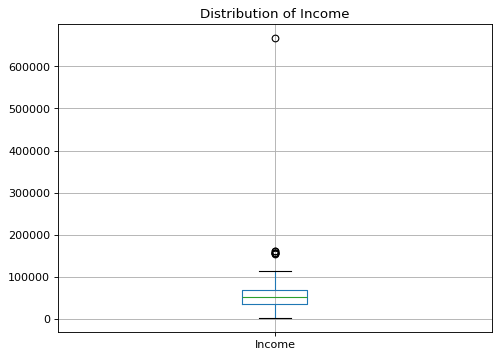

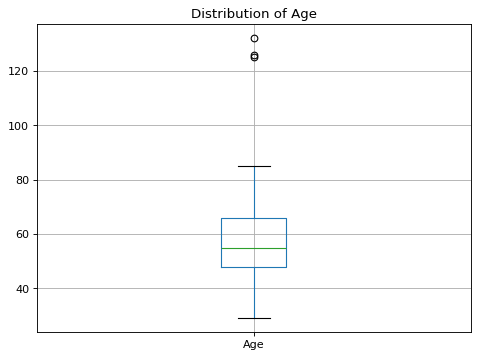

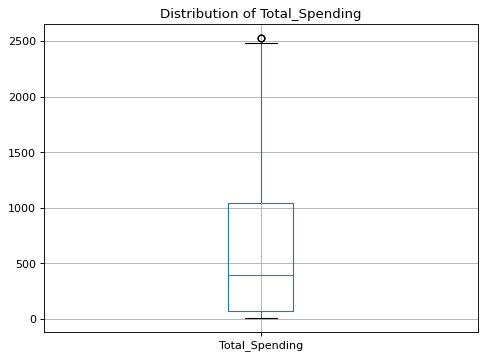

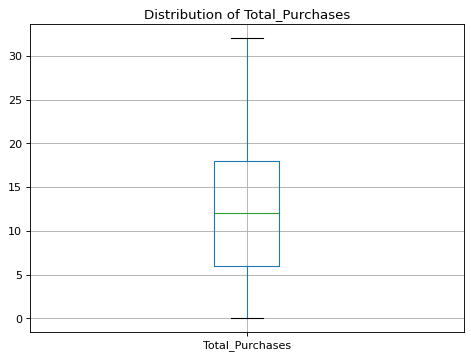

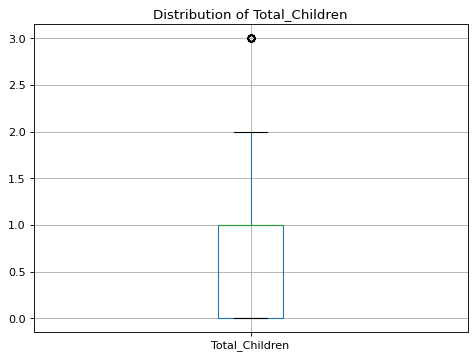

In [ ]:
# plotting to get insights into the distributions and identifing  outliers
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['Income', 'Age', 'Total_Spending', 'Total_Purchases', 'Total_Children']

for col in num_cols:
  plt.figure(figsize=(7,5), dpi=80)
  df.boxplot(column=col)
  plt.title(f'Distribution of {col}')
  plt.show()


<Figure size 560x400 with 0 Axes>

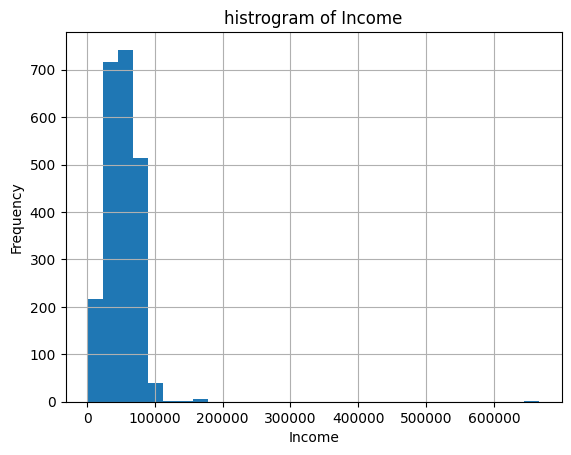

<Figure size 560x400 with 0 Axes>

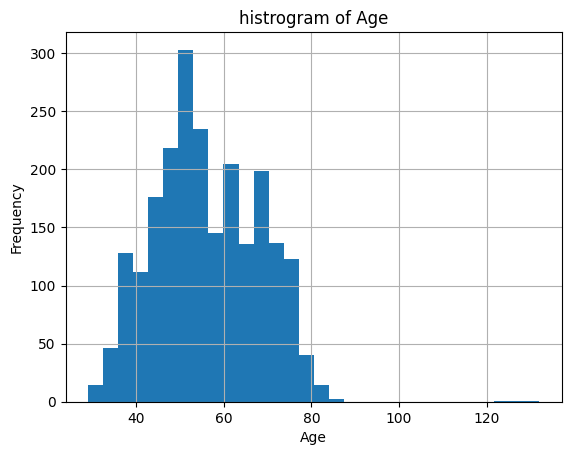

<Figure size 560x400 with 0 Axes>

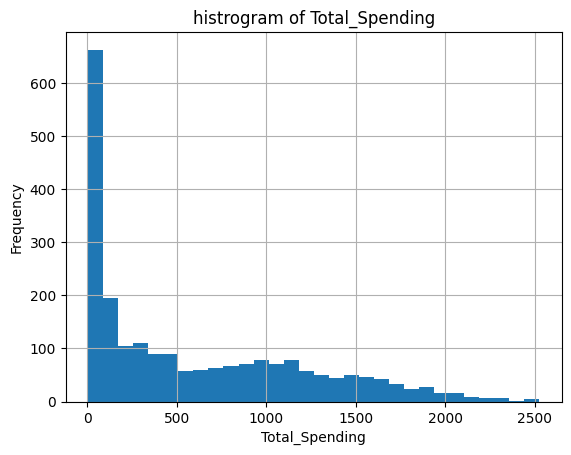

<Figure size 560x400 with 0 Axes>

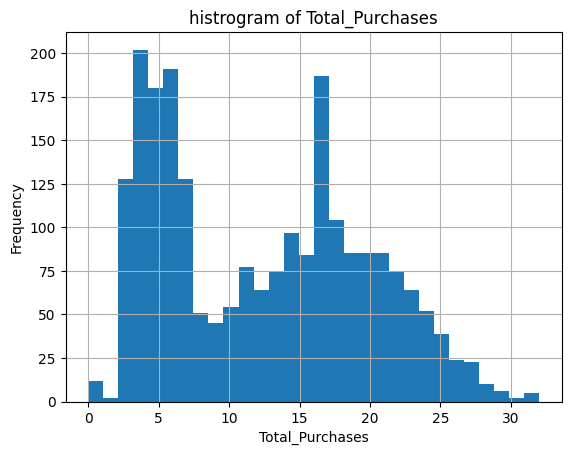

<Figure size 560x400 with 0 Axes>

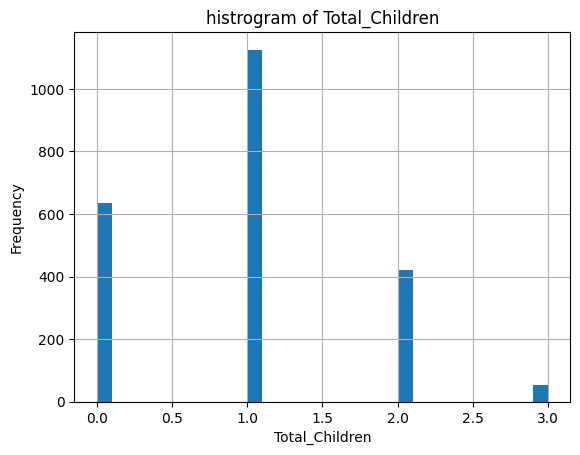

 'Income' plot is right-skewed
 'Total_Spending'plot is right-skewed
 'Age' plot is normal distribution
'Total_Children' plot is discrete & low range


In [ ]:
# histograms
for col in num_cols:
  plt.figure(figsize=(7,5), dpi=80)
  df.hist(column=col, bins=30)
  plt.title(f'histrogram of {col}')
  plt.xlabel(col)
  plt.ylabel('Frequency')
  plt.show()

print(" 'Income' plot is right-skewed")
print(" 'Total_Spending'plot is right-skewed")
print(" 'Age' plot is normal distribution")
print("'Total_Children' plot is discrete & low range")

In [ ]:
# Outlier detection using IQR method
def detect_outliers(df, column):
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  IQR = Q3 -Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  df[column] = df[column].clip(lower_bound, upper_bound)
  return df

outlier_cols = ['Income', 'Total_Spending', 'Age', 'Total_Purchases']
for col in outlier_cols:
  df = detect_outliers(df, col)

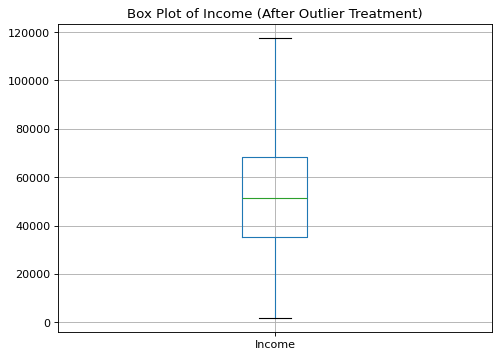

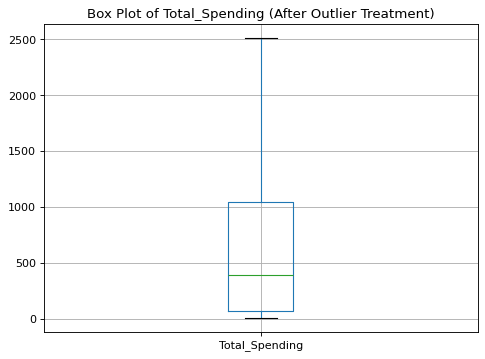

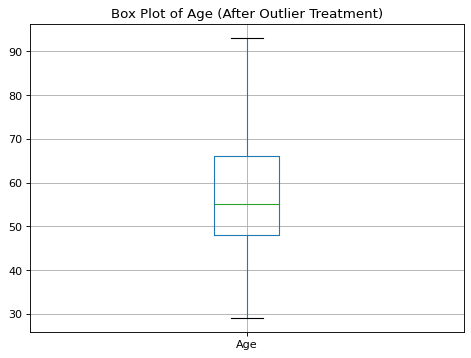

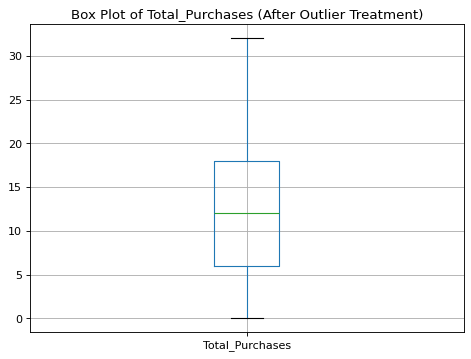

In [ ]:
for col in outlier_cols:
    plt.figure(figsize=(7,5), dpi=80)
    df.boxplot(column=col)
    plt.title(f'Box Plot of {col} (After Outlier Treatment)')
    plt.show()


**Task 5: Ordinal & One-Hot Encoding**

In [ ]:
# identify the categorical variables in data set
# Ordinal Encoding for Education
df['Education'] = df['Education'].replace({
    'Basic': 'Undergraduate',
    'Graduation': 'Undergraduate',
    '2n Cycle': 'Postgraduate'
})


In [ ]:
education_order = {
    'Undergraduate': 1,
    'Postgraduate': 2,
    'Master': 3,
    'PhD': 4
}

df['Education_Ordinal'] = df['Education'].map(education_order)
df[['Education', 'Education_Ordinal']].head()

,Education,Education_Ordinal
0,Undergraduate,1
1,Undergraduate,1
2,Undergraduate,1
3,Undergraduate,1
4,Undergraduate,1


In [ ]:
df[df['Education_Ordinal'].isna()]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country,Total_Children,Age,Total_Spending,Total_Purchases,Education_Ordinal


In [ ]:
# One-Hot Encoding (Marital_Status)
print(df.columns)



Index(['ID', 'Year_Birth', 'Education', 'Income', 'Kidhome', 'Teenhome',
       'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3',
       'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2',
       'Response', 'Complain', 'Country', 'Total_Children', 'Age',
       'Total_Spending', 'Total_Purchases', 'Education_Ordinal',
       'Marital_Status_Married', 'Marital_Status_Single',
       'Marital_Status_Together', 'Marital_Status_Widow'],
      dtype='object')


In [ ]:
[col for col in df.columns if col.startswith('Marital_Status_')]

['Marital_Status_Married',
 'Marital_Status_Single',
 'Marital_Status_Together',
 'Marital_Status_Widow']

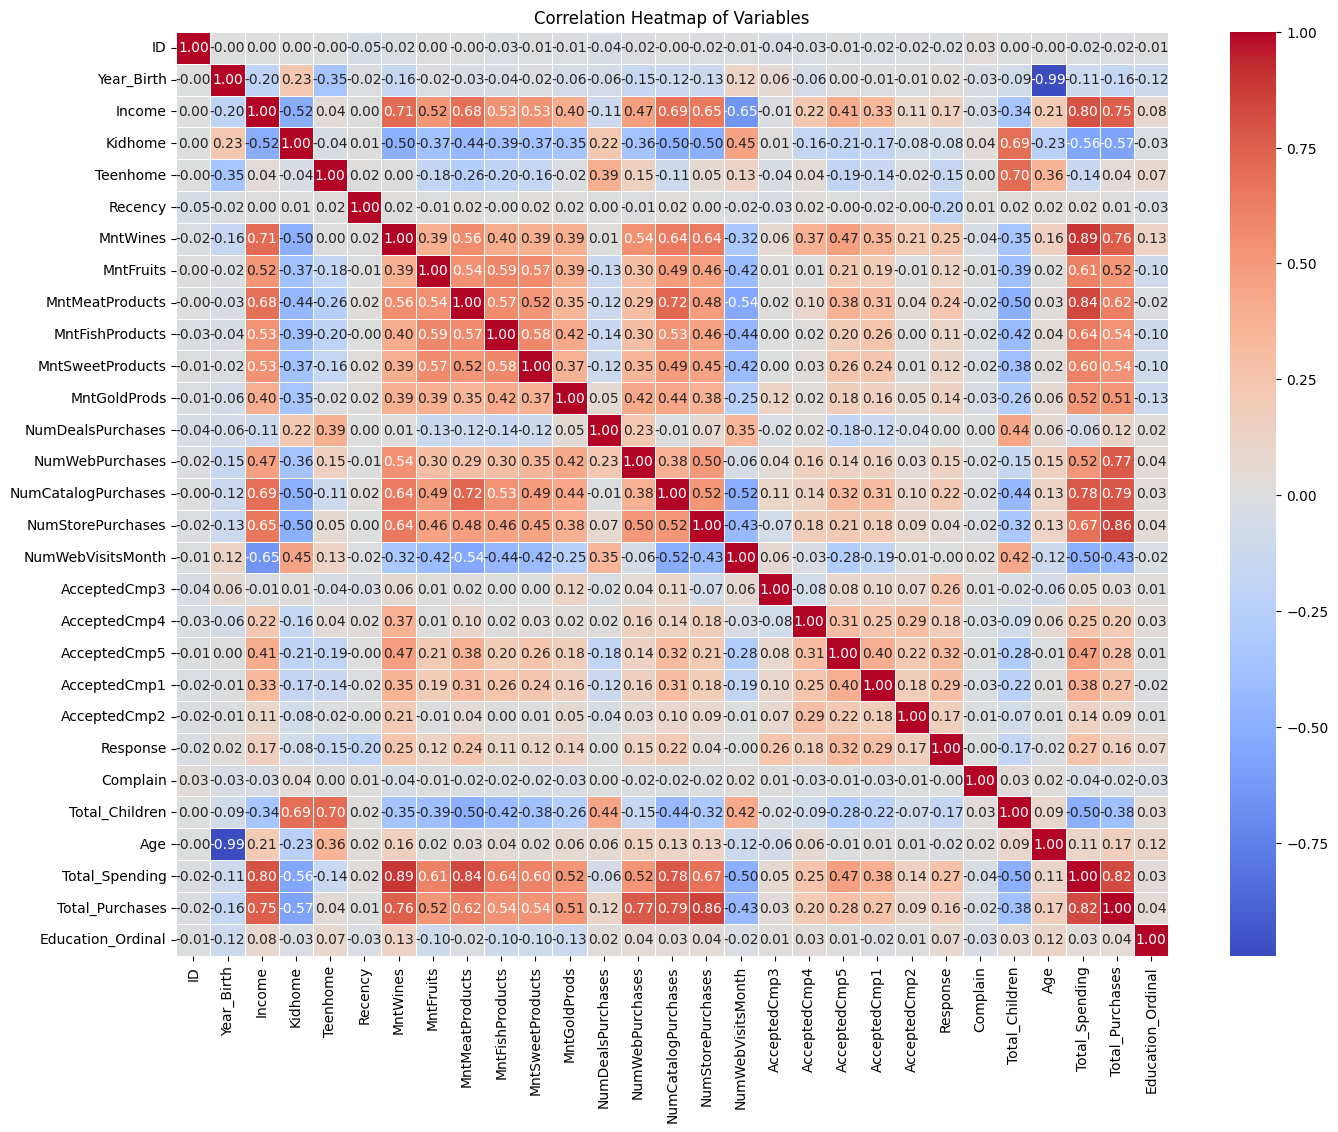

In [ ]:
# Generate a Heatmap of Correlations
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr()
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Variables')
plt.show()

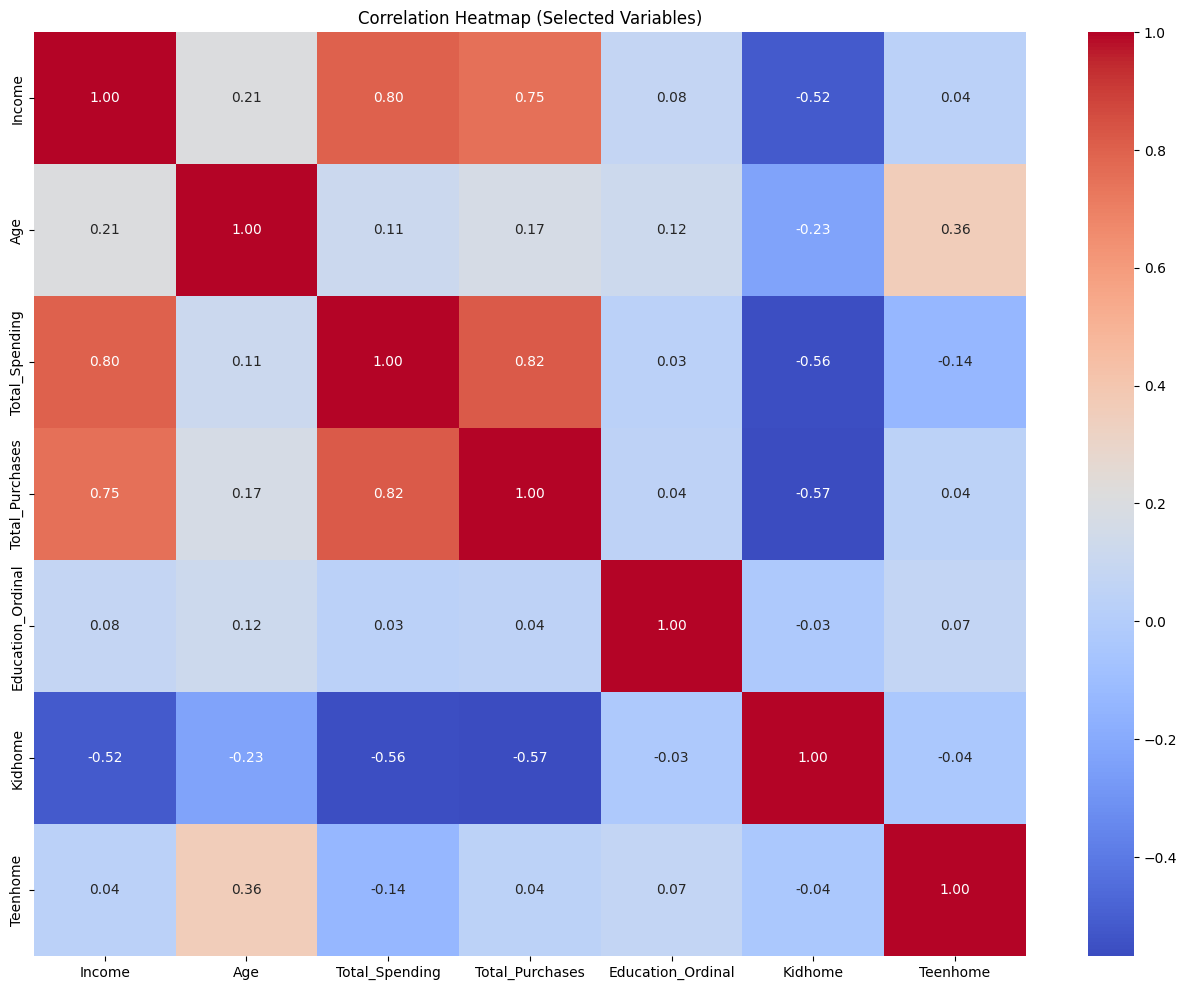

In [ ]:
selected_features = [
    'Income', 'Age', 'Total_Spending', 'Total_Purchases',
    'Education_Ordinal', 'Kidhome', 'Teenhome'
]

plt.figure(figsize=(16, 12))
sns.heatmap(
    df[selected_features].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Correlation Heatmap (Selected Variables)')
plt.show()


**STEP 7: Hypothesis Testing**

In [ ]:
# a. Older individuals prefer in-store shopping over online shopping
df[['Age', 'NumStorePurchases', 'NumWebPurchases']].corr()


,Age,NumStorePurchases,NumWebPurchases
Age,1.000000,0.134918,0.150991
NumStorePurchases,0.134918,1.000000,0.502951
NumWebPurchases,0.150991,0.502951,1.000000


In [25]:
# b. Customers with children prefer online shopping due to time constraints
df[['Total_Children', 'NumWebPurchases']].corr()

,Total_Children,NumWebPurchases
Total_Children,1.000000,-0.146361
NumWebPurchases,-0.146361,1.000000


In [14]:
# c. Physical store sales are cannibalized by other channels
df[['NumStorePurchases', 'NumWebPurchases', 'NumCatalogPurchases']].corr()


,NumStorePurchases,NumWebPurchases,NumCatalogPurchases
NumStorePurchases,1.000000,0.502713,0.518738
NumWebPurchases,0.502713,1.000000,0.378376
NumCatalogPurchases,0.518738,0.378376,1.000000


In [46]:
# d. Does the United States outperform the rest of the world in purchases?
us_purchases = df[df['Country'] == 'USA']['Total_Purchases']
non_us_purchases = df[df['Country'] != 'USA']['Total_Purchases']

print("USA sample size:", us_purchases.shape[0])
print("Non-USA sample size:", non_us_purchases.shape[0])


USA sample size: 0
Non-USA sample size: 2240


**Performin : T-Test**

In [54]:
us_purchases = us_purchases.dropna()
non_us_purchases = non_us_purchases.dropna()
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(
    us_purchases,
    non_us_purchases,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)


T-statistic: nan
P-value: nan


/usr/local/lib/python3.12/dist-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


**Observation:** The USA group is missing or extremely small and
Variance cannot be computed.Hence, t-test is "NaN". the dataset does not contain sufficient observations for customers from the United States, it is not possible to conduct a valid statistical test.

**STEP 8: Data Visualization**

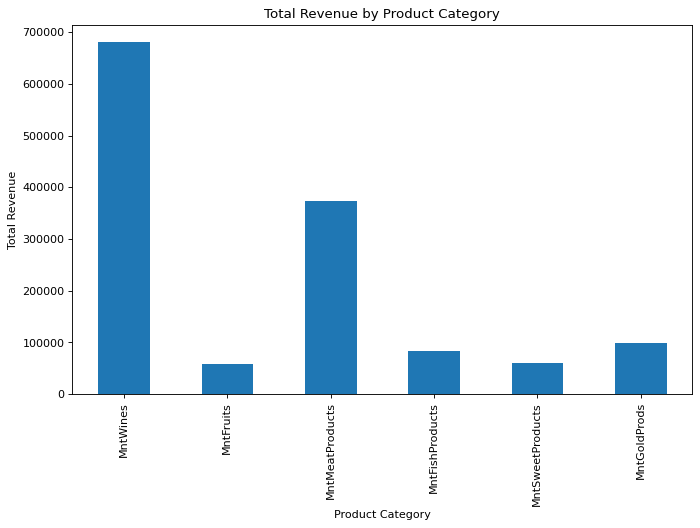

In [57]:
# a. Identify top-performing products and lowest revenue products
# plotting bar chart
import matplotlib.pyplot as plt
import pandas as pd
product_sales = df[[
    'MntWines', 'MntFruits', 'MntMeatProducts',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds'
]].sum()

plt.figure(figsize=(10,6), dpi=80)
product_sales.plot(kind='bar')
plt.title('Total Revenue by Product Category')
plt.ylabel('Total Revenue')
plt.xlabel('Product Category')
plt.show()

**Observation:**  Highest bar → top-performing product

Lowest bar → lowest revenue product

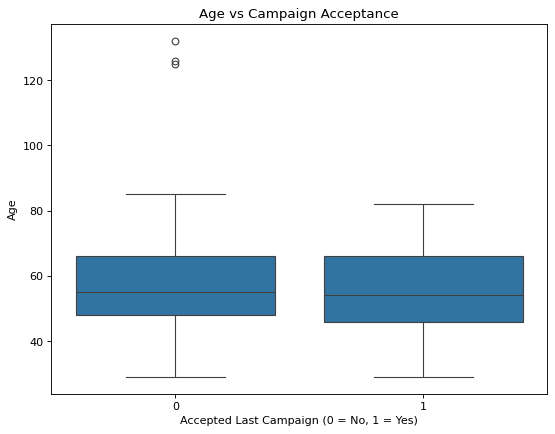

In [65]:
# b. Correlation between Age and acceptance of the last campaign
# plotting box plot
plt.figure(figsize=(8, 6), dpi=80)
sns.boxplot(x='Response', y='Age', data=df)
plt.title('Age vs Campaign Acceptance')
plt.xlabel('Accepted Last Campaign (0 = No, 1 = Yes)')
plt.ylabel('Age')
plt.show()





**Observation:** If median age is higher for Response = 1 → older customers accepted more.

Overlapping boxes → weak or no relationship

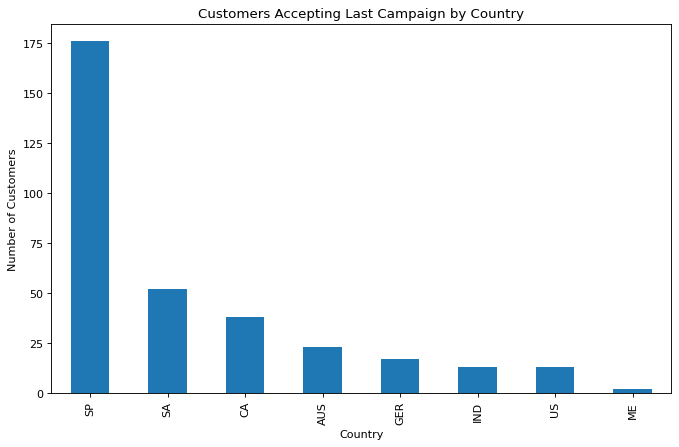

In [67]:
# c. Country with the highest number of customers who accepted the last campaign
accepted_by_country = (
    df[df['Response'] == 1].groupby('Country').size()
    .sort_values(ascending=False))

plt.figure(figsize=(10, 6), dpi=80)
accepted_by_country.plot(kind='bar')
plt.title('Customers Accepting Last Campaign by Country')
plt.ylabel('Number of Customers')
plt.xlabel('Country')
plt.show()



**Observation:** Tallest bar "SP" country with highest campaign acceptance

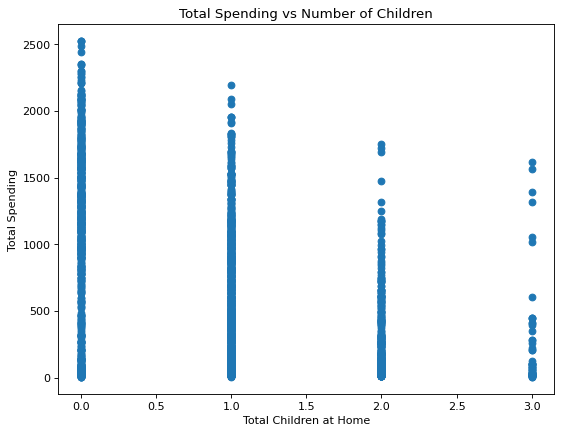

In [79]:
# d. Pattern between number of children and total expenditure
# Scatter Plot

plt.figure(figsize=(8, 6), dpi=80)
plt.scatter(df['Total_Children'], df['Total_Spending'])
plt.title('Total Spending vs Number of Children')
plt.xlabel('Total Children at Home')
plt.ylabel('Total Spending')
plt.show()

**Observation:** No clear pattern therefor weak relationship and Downward trend shows that more children, less spending

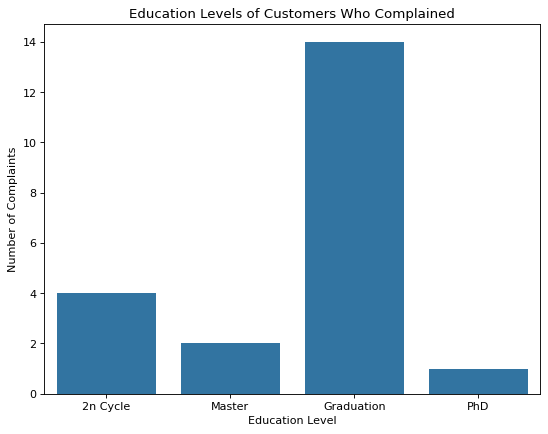

In [80]:
# e. Educational background of customers who lodged complaints
# count plot
plt.figure(figsize=(8, 6), dpi=80)
sns.countplot(
    data=df[df['Complain'] == 1],
    x='Education'
)
plt.title('Education Levels of Customers Who Complained')
plt.xlabel('Education Level')
plt.ylabel('Number of Complaints')
plt.show()


**Observation:** Highest bar i.e. education group with most complaints